In [4]:
#Import libraries and load data
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
import re
import matplotlib.pyplot as plt
import seaborn as sns


file_path = r'C:/Users/user/Desktop/Level 4 Final Projects/Digital Footprint Analysis/browser_history_exports/browser_history.xlsx'

# Load dataset 
if file_path.endswith('.xlsx'):
    df = pd.read_excel(file_path, parse_dates=['Last Visit'])
else:  
    df = pd.read_csv(file_path, encoding='latin1', parse_dates=['Last Visit'])

# Display first 5 rows 
df.head()

,Browser,Title,URL,Visit Count,Last Visit
0,chrome,how to bypass paywall - Google Search,https://www.google.com/search?q=how+to+bypass+...,1,2025-04-10 19:40:46
1,chrome,myMSU | Dashboard,https://elearning.msu.ac.zw/#!/,142,2025-04-10 19:40:40
2,chrome,myMSU | Dashboard,https://elearning.msu.ac.zw/#,84,2025-04-10 19:40:40
3,chrome,myMSU | Dashboard,https://elearning.msu.ac.zw/#!/assessment,20,2025-04-10 19:40:36
4,chrome,myMSU | Dashboard,https://elearning.msu.ac.zw/,90,2025-04-10 19:40:28


In [5]:
#Data cleaning
# Clean text columns
df['Browser'] = df['Browser'].str.lower().str.strip().fillna('unknown')
df['Title'] = df['Title'].str.lower().str.strip().fillna('')
df['URL'] = df['URL'].str.lower().str.strip().fillna('')

# Extract domain from URL
def extract_domain(url):
    match = re.search(r'(https?://)?(www\.)?([a-z0-9-]+)(\.[a-z]{2,}){1,2}', url)
    return match.group(3) if match else 'unknown'

df['domain'] = df['URL'].apply(extract_domain)
df[['URL', 'domain']].head()

,URL,domain
0,https://www.google.com/search?q=how+to+bypass+...,google
1,https://elearning.msu.ac.zw/#!/,elearning
2,https://elearning.msu.ac.zw/#,elearning
3,https://elearning.msu.ac.zw/#!/assessment,elearning
4,https://elearning.msu.ac.zw/,elearning


In [6]:
#Enhanced threat patterns
threat_patterns = {
    'betting': r'\b(bet|betting|gambl|casino|poker|sportsbook|wager|odds|slot)\b',
    'porn': r'\b(porn|xxx|adult|sex|fuck|nude|nsfw|webcam|escort)\b',
    'social': r'\b(facebook|instagram|twitter|tiktok|social[\s-]?media|linkedin)\b',
    'video': r'\b(youtube|vimeo|dailymotion|stream|twitch|netflix)\b',
    'trading': r'\b(forex|crypto|bitcoin|trading|binance|coinbase|kraken|mt[45])\b',
    'hacking': r'\b(hack|crack|keygen|cheat|exploit|bypass|ddos|injection)\b',
    'money': r'\b(western[\s-]?union|money[\s-]?gram|paypal|venmo|cash[\s-]?app)\b',
    'cloud': r'\b(dropbox|google[\s-]?drive|mega(\.nz)?|onedrive|box(\.com)?)\b',
    'anonymous': r'\b(tor|vpn|proxy|anonymous|incognito|hide[\s-]?ip)\b',
    'shopping': r'\b(amazon|ebay|alibaba|etsy|shopify|walmart|target)\b',
    'job': r'\b(linkedin|indeed|monster|career|job|employment)\b',
    'forum': r'\b(reddit|forum|4chan|discord|telegram|whatsapp)\b'
}

# Apply threat detection
for category, pattern in threat_patterns.items():
    df[f'is_{category}'] = (
        df['Title'].str.contains(pattern, case=False, regex=True) | 
        df['URL'].str.contains(pattern, case=False, regex=True) |
        df['domain'].str.contains(pattern, case=False, regex=True)
    ).astype(int)

# Show threat detection results
df[[col for col in df.columns if col.startswith('is_')]].sum().sort_values(ascending=False)

C:\Users\user\AppData\Local\Temp\ipykernel_21768\1305215840.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['Title'].str.contains(pattern, case=False, regex=True) |
C:\Users\user\AppData\Local\Temp\ipykernel_21768\1305215840.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['URL'].str.contains(pattern, case=False, regex=True) |
C:\Users\user\AppData\Local\Temp\ipykernel_21768\1305215840.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['domain'].str.contains(pattern, case=False, regex=True)
C:\Users\user\AppData\Local\Temp\ipykernel_21768\1305215840.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['Title'].str

is_video        1654
is_social        339
is_cloud         164
is_job            66
is_forum          25
is_shopping       22
is_trading         9
is_hacking         9
is_betting         5
is_porn            3
is_money           0
is_anonymous       0
dtype: int64

In [7]:
#Time-based features
df['hour'] = df['Last Visit'].dt.hour
df['weekday'] = df['Last Visit'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)
df['late_night'] = ((df['hour'] >= 23) | (df['hour'] <= 5)).astype(int)

# URL features
df['url_length'] = df['URL'].str.len()
df['url_depth'] = df['URL'].str.count('/') - 2
df['has_query'] = df['URL'].str.contains(r'\?', regex=False).astype(int)

# Behavioral features
df['browser_code'] = LabelEncoder().fit_transform(df['Browser'])
df['visits_per_hour'] = df.groupby(
    [df['Last Visit'].dt.date, df['Last Visit'].dt.hour]
)['Visit Count'].transform('sum')

df[['hour', 'weekday', 'is_weekend', 'late_night', 'url_length', 'visits_per_hour']].describe()

,hour,weekday,is_weekend,late_night,url_length,visits_per_hour
count,6677.000000,6677.000000,6677.000000,6677.000000,6677.000000,6677.000000
mean,14.843493,3.328591,0.362888,0.061854,193.518646,57.858919
std,5.342738,2.098070,0.480869,0.240908,295.196515,185.204641
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,11.000000,1.000000,0.000000,0.000000,45.000000,16.000000
50%,16.000000,4.000000,0.000000,0.000000,79.000000,32.000000
75%,19.000000,5.000000,1.000000,0.000000,193.000000,62.000000
max,23.000000,6.000000,1.000000,1.000000,2644.000000,3018.000000


In [8]:
#Prepare features for Isolation Forest
features = [
    'is_betting', 'is_porn', 'is_trading', 'is_hacking', 'is_money',
    'hour', 'is_weekend', 'late_night', 'url_length', 'url_depth',
    'has_query', 'visits_per_hour', 'browser_code'
]

X = df[features]

# Train Isolation Forest
model = IsolationForest(
    n_estimators=150,
    max_samples=0.8,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
model.fit(X)

# Add predictions
df['anomaly_score'] = model.decision_function(X)
df['is_anomaly'] = model.predict(X)

# Show results
df[['Browser', 'Title', 'URL', 'anomaly_score', 'is_anomaly']].sort_values('anomaly_score').head(10)

,Browser,Title,URL,anomaly_score,is_anomaly
5254,edge,meet - dch-pnsa-dbg,https://meet.google.com/accounts/setosid?authu...,-0.210090,-1
0,chrome,how to bypass paywall - google search,https://www.google.com/search?q=how+to+bypass+...,-0.209578,-1
225,chrome,attachment projects - onedrive,https://onedrive.live.com/?view=1&sw=bypass&by...,-0.207663,-1
226,chrome,continue,https://onedrive.live.com/?sw=bypass&bypassrea...,-0.207292,-1
4716,edge,password,https://myaccount.google.com/accounts/setosid?...,-0.198259,-1
4702,edge,sign in – google accounts,https://accounts.google.com/o/oauth2/v2/auth?c...,-0.192601,-1
4703,edge,sign in – google accounts,https://accounts.google.com/o/oauth2/v2/auth?c...,-0.192601,-1
4328,edge,gweru city council logos - search images,https://www.bing.com/images/search?view=detail...,-0.181788,-1
2149,chrome,cheat sheets,https://classroom.google.com/u/1/c/nzq5odgxmzm...,-0.172944,-1
468,chrome,start trading with a welcome bonus and unlock ...,https://www.xm.com/affiliate_tracking?affid=11...,-0.172584,-1


In [9]:
#risk scoring
# Define category weights
category_weights = {
    'betting': 0.9,
    'porn': 1.0,
    'trading': 0.8,
    'hacking': 1.0,
    'money': 0.7,
    'cloud': 0.6,
    'anonymous': 0.8,
    'social': 0.4,
    'video': 0.3,
    'shopping': 0.2,
    'job': 0.5,
    'forum': 0.4
}

# Calculate threat score
df['threat_score'] = 0
for category in threat_patterns.keys():
    df['threat_score'] += df[f'is_{category}'] * category_weights.get(category, 0.5)

# Combine with anomaly score
df['composite_risk'] = 0.6 * df['threat_score'] + 0.4 * (1 - df['anomaly_score'])

# Risk levels
bins = [0, 0.3, 0.6, 0.8, 1]
labels = ['Low', 'Medium', 'High', 'Critical']
df['risk_level'] = pd.cut(df['composite_risk'], bins=bins, labels=labels)

# Show high-risk activities
high_risk = df[df['risk_level'].isin(['High', 'Critical'])].sort_values('composite_risk', ascending=False)
high_risk[['Browser', 'Title', 'URL', 'Last Visit', 'risk_level', 'composite_risk']].head(20)

,Browser,Title,URL,Last Visit,risk_level,composite_risk
277,chrome,premier bet zimbabwe,https://x2tsa.com/fwd.php?c=4102&s=7fe0c7973af...,2025-04-08 19:14:16,Critical,0.993816
276,chrome,premier bet zimbabwe,https://x2tsa.com/trk.php?c=4102&s=8490013&t=9...,2025-04-08 19:14:16,Critical,0.993291
468,chrome,start trading with a welcome bonus and unlock ...,https://www.xm.com/affiliate_tracking?affid=11...,2025-04-06 13:00:30,Critical,0.949034
560,chrome,iq option - ultimate trading platform. join th...,https://iqoption.com/land/start-trading/en/?af...,2025-04-05 13:06:30,Critical,0.944757
561,chrome,iq option - ultimate trading platform. join th...,https://iqbroker.com/land/start-trading/en/?af...,2025-04-05 13:06:30,Critical,0.944757
467,chrome,start trading with a welcome bonus and unlock ...,https://clicks.pipaffiliates.com/c?c=968959&l=...,2025-04-06 13:00:30,Critical,0.941229
469,chrome,start trading with a welcome bonus and unlock ...,https://www.xm.com/promotions?utm_source=dread...,2025-04-06 13:00:30,Critical,0.939584
909,chrome,iq option - ultimate trading platform. join th...,https://iqoption.com/land/start-trading/en/?af...,2025-04-01 18:33:48,Critical,0.937965
910,chrome,iq option - ultimate trading platform. join th...,https://iqbroker.com/land/start-trading/en/?af...,2025-04-01 18:33:48,Critical,0.937965
908,chrome,iq option - ultimate trading platform. join th...,https://track.topoffercheck.online/66f51d02a8e...,2025-04-01 18:33:48,Critical,0.936555


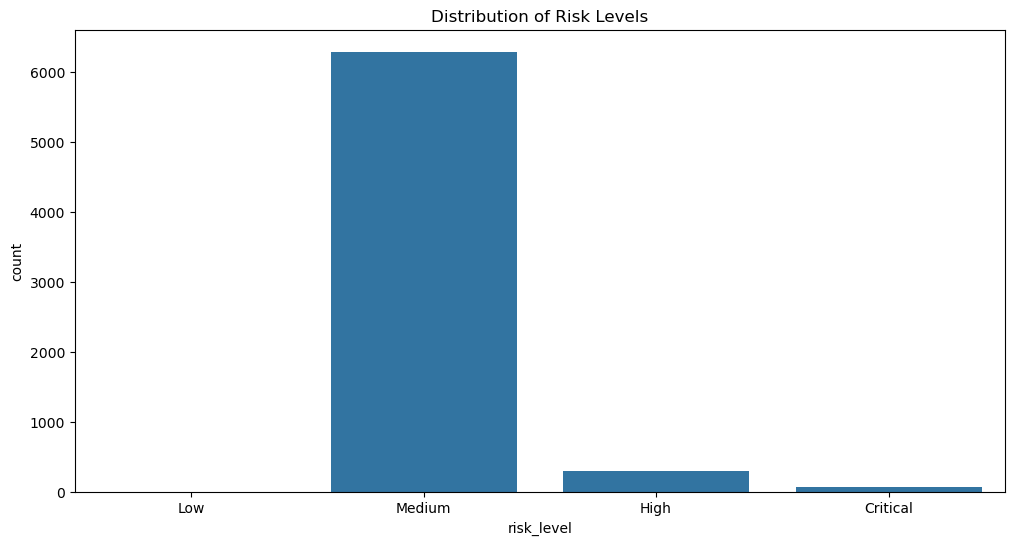

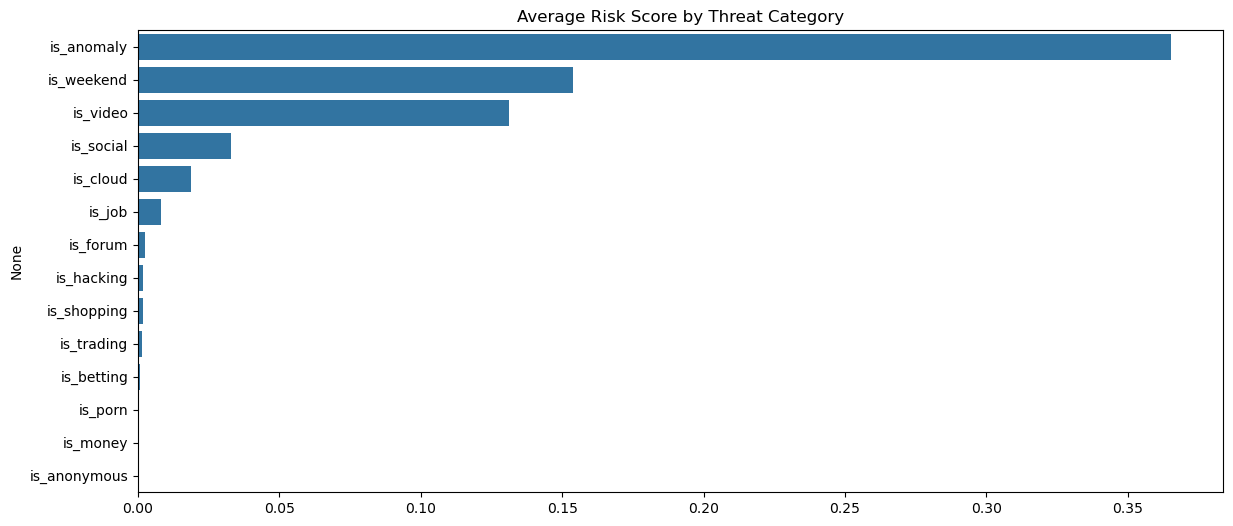

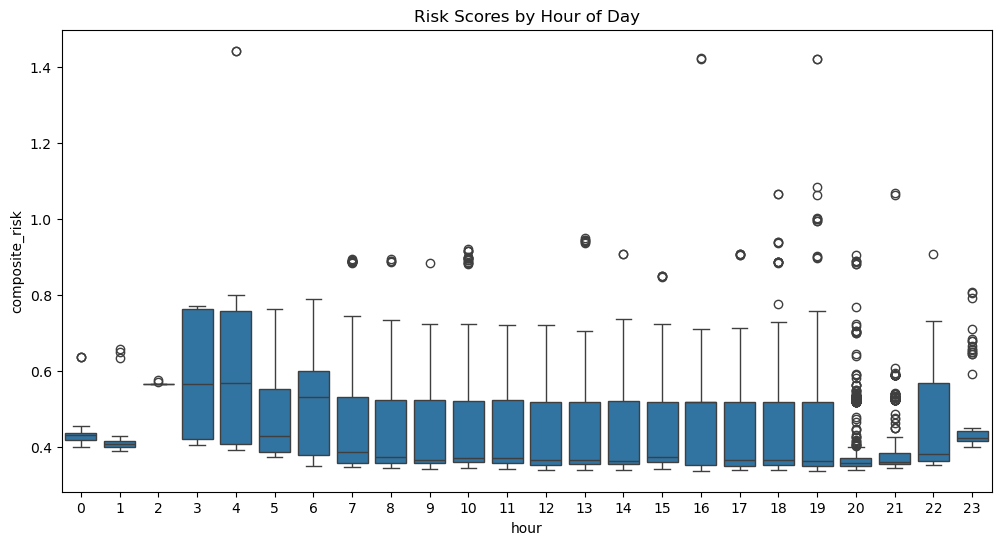

In [10]:
#Visualization
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='risk_level', order=labels)
plt.title('Distribution of Risk Levels')
plt.show()

plt.figure(figsize=(14, 6))
risk_by_category = df[[col for col in df.columns if col.startswith('is_')]].multiply(df['composite_risk'], axis=0).mean().sort_values(ascending=False)
sns.barplot(x=risk_by_category.values, y=risk_by_category.index)
plt.title('Average Risk Score by Threat Category')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='hour', y='composite_risk')
plt.title('Risk Scores by Hour of Day')
plt.show()